<a href="https://colab.research.google.com/github/codewithtrisha09/ML-LAB/blob/main/WEEK_03DATA_PREPROCESSING_AND_REGRESSION_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

WEEK 3 DATA PREPROCESSING AND REGRESSION

Q1 Consider the hepatitis/ pima-indians-diabetes csv file, perform the following date pre-processing.
1. Load data in Pandas.
2. Drop columns that aren’t useful.
3. Drop rows with missing values.
4. Create dummy variables.
5. Take care of missing data.
6. Convert the data frame to NumPy.
7. Divide the data set into training data and test data

1.Load data in Pandas.

In [ ]:
import pandas as pd
import numpy as np

df=pd.read_csv("Week 3 hepatitis_csv.csv")
print("Original Dataset")
print(df.head())

Original Dataset
   age     sex steroid  antivirals fatigue malaise anorexia liver_big  \
0   30    male   False       False   False   False    False     False   
1   50  female   False       False    True   False    False     False   
2   78  female    True       False    True   False    False      True   
3   31  female     NaN        True   False   False    False      True   
4   34  female    True       False   False   False    False      True   

  liver_firm spleen_palpable spiders ascites varices  bilirubin  \
0      False           False   False   False   False        1.0   
1      False           False   False   False   False        0.9   
2      False           False   False   False   False        0.7   
3      False           False   False   False   False        0.7   
4      False           False   False   False   False        1.0   

   alk_phosphate   sgot  albumin  protime  histology class  
0           85.0   18.0      4.0      NaN      False  live  
1          135.0   

In [ ]:
print(df.columns)

Index(['age', 'sex', 'steroid', 'antivirals', 'fatigue', 'malaise', 'anorexia',
       'liver_big', 'liver_firm', 'spleen_palpable', 'spiders', 'ascites',
       'varices', 'bilirubin', 'alk_phosphate', 'sgot', 'albumin', 'protime',
       'histology', 'class'],
      dtype='object')


2.Drop columns that aren’t useful.

In [ ]:
if 'ID' in df.columns:
    df.drop('ID',axis=1,inplace=True)

3.Drop rows with missing values.

In [ ]:
df=df.dropna()
print(df.head())

    age     sex steroid  antivirals fatigue malaise anorexia liver_big  \
5    34  female    True       False   False   False    False      True   
10   39  female   False        True   False   False    False     False   
11   32  female    True        True    True   False    False      True   
12   41  female    True        True    True   False    False      True   
13   30  female    True       False    True   False    False      True   

   liver_firm spleen_palpable spiders ascites varices  bilirubin  \
5       False           False   False   False   False        0.9   
10       True           False   False   False   False        1.3   
11       True           False    True   False   False        1.0   
12       True           False   False   False   False        0.9   
13       True           False   False   False   False        2.2   

    alk_phosphate   sgot  albumin  protime  histology class  
5            95.0   28.0      4.0     75.0      False  live  
10           78.0   30

4.Create dummy variables.

In [ ]:
df=pd.get_dummies(df,drop_first=True)

5.Take care of missing data

In [ ]:
df=df.fillna(df.mean(numeric_only=True))
print(df.head())

    age  antivirals  bilirubin  alk_phosphate   sgot  albumin  protime  \
5    34       False        0.9           95.0   28.0      4.0     75.0   
10   39        True        1.3           78.0   30.0      4.4     85.0   
11   32        True        1.0           59.0  249.0      3.7     54.0   
12   41        True        0.9           81.0   60.0      3.9     52.0   
13   30       False        2.2           57.0  144.0      4.9     78.0   

    histology  sex_male  steroid_True  fatigue_True  malaise_True  \
5       False         0             1             0             0   
10      False         0             0             0             0   
11      False         0             1             1             0   
12      False         0             1             1             0   
13      False         0             1             1             0   

    anorexia_True  liver_big_True  liver_firm_True  spleen_palpable_True  \
5               0               1                0              

6.Convert the data frame to NumPy.

In [ ]:
data=df.to_numpy()
print("\n Numpy Array:\n")
print(data)


 Numpy Array:

[[34 False 0.9 ... 0 0 1]
 [39 True 1.3 ... 0 0 1]
 [32 True 1.0 ... 0 0 1]
 ...
 [31 False 1.2 ... 0 0 1]
 [53 False 1.5 ... 0 1 1]
 [43 False 1.2 ... 1 0 0]]


7.Divide the data set into training data and test data

In [ ]:
print(df.columns)

Index(['age', 'antivirals', 'bilirubin', 'alk_phosphate', 'sgot', 'albumin',
       'protime', 'histology', 'sex_male', 'steroid_True', 'fatigue_True',
       'malaise_True', 'anorexia_True', 'liver_big_True', 'liver_firm_True',
       'spleen_palpable_True', 'spiders_True', 'ascites_True', 'varices_True',
       'class_live'],
      dtype='object')


In [ ]:
target='class_live'
X=df.drop(columns=[target]).to_numpy()
y=df[target].to_numpy()
np.random.seed(42)
indices=np.random.permutation(len(X))
test_size = int(0.2 * len(X))
test_indices = indices[:test_size]
train_indices = indices[test_size:]
X_train = X[train_indices]
X_test = X[test_indices]
y_train = y[train_indices]
y_test = y[test_indices]
print("\nTraining Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)
print("Training Labels Shape:", y_train.shape)
print("Testing Labels Shape:", y_test.shape)



Training Data Shape: (64, 19)
Testing Data Shape: (16, 19)
Training Labels Shape: (64,)
Testing Labels Shape: (16,)


Q1 (Using Diabetes dataset)

In [ ]:
import pandas as pd
import numpy as np

df=pd.read_csv("Week 3 diabetes_csv.csv")
print("Original Dataset")
print(df.head())

Original Dataset
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  


In [ ]:
if 'ID' in df.columns:
    df.drop('ID',axis=1,inplace=True)

In [ ]:
df=df.dropna()
print(df.head())

   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  


In [ ]:
df=pd.get_dummies(df,drop_first=True)

In [ ]:
df=df.fillna(df.mean(numeric_only=True))
print(df.head())

   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  


In [ ]:
data=df.to_numpy()
print("\n Numpy Array:\n")
print(data)


 Numpy Array:

[[  6.    148.     72.    ...   0.627  50.      1.   ]
 [  1.     85.     66.    ...   0.351  31.      0.   ]
 [  8.    183.     64.    ...   0.672  32.      1.   ]
 ...
 [  5.    121.     72.    ...   0.245  30.      0.   ]
 [  1.    126.     60.    ...   0.349  47.      1.   ]
 [  1.     93.     70.    ...   0.315  23.      0.   ]]


In [ ]:
print(df.columns)

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')


In [ ]:
target='Outcome'
X=df.drop(columns=[target]).to_numpy()
y=df[target].to_numpy()
np.random.seed(42)
indices=np.random.permutation(len(X))
test_size = int(0.2 * len(X))
test_indices = indices[:test_size]
train_indices = indices[test_size:]
X_train = X[train_indices]
X_test = X[test_indices]
y_train = y[train_indices]
y_test = y[test_indices]
print("\nTraining Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)
print("Training Labels Shape:", y_train.shape)
print("Testing Labels Shape:", y_test.shape)


Training Data Shape: (615, 8)
Testing Data Shape: (153, 8)
Training Labels Shape: (615,)
Testing Labels Shape: (153,)


Q2 a. Construct a CSV file with the following attributes:
Study time in hours of ML lab course (x)
Score out of 10 (y)
The dataset should contain 10 rows.
b. Create a regression model and display the following:
Coefficients: B0 (intercept) and B1 (slope)
RMSE (Root Mean Square Error)
Predicted responses
c. Create a scatter plot of the data points in red color and plot the graph of x vs. predicted y in blue color.
d. Implement the model using two methods:
Pedhazur formula (intuitive)
Calculus method (partial derivatives, refer to class notes)
e. Compare the coefficients obtained using both methods and compare them with the analytical solution.
f. Test your model to predict the score obtained when the study time of a student is 10 hours

StudyTime,Score
1,2
2,3
3,4
4,4
5,5
6,7
7,7
8,8
9,9
10,10

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
df=pd.read_csv('study_score.csv')

print(df.columns)

Index(['StudyTime', 'Scores'], dtype='object')


In [ ]:
x = df["StudyTime"].values
y = df["Scores"].values

n = len(x)
print(n)

10


In [ ]:
x_mean=np.mean(x)
y_mean=np.mean(y)
print(x_mean)
print(y_mean)

5.5
5.9


In [ ]:
B1 = np.sum((x - x_mean) * (y - y_mean)) / np.sum((x - x_mean)**2)
B0 = y_mean - B1 * x_mean
print("By Pedhazur Method:\n")
print("Slope(B1): ",B1)
print("Intercept(B0): ",B0)

y_pred=B0+B1*x
rmse = np.sqrt(np.mean((y - y_pred)**2))
print("RMSE:", rmse)
print("\nPredicted Responses")
print(y_pred)
error=y-y_pred
print("\nError: \n",error)

By Pedhazur Method:

Slope(B1):  0.8787878787878788
Intercept(B0):  1.0666666666666673
RMSE: 0.34465617474213156

Predicted Responses
[1.94545455 2.82424242 3.7030303  4.58181818 5.46060606 6.33939394
 7.21818182 8.0969697  8.97575758 9.85454545]

Error: 
 [ 0.05454545  0.17575758  0.2969697  -0.58181818 -0.46060606  0.66060606
 -0.21818182 -0.0969697   0.02424242  0.14545455]


In [ ]:
sum_x = np.sum(x)
sum_y = np.sum(y)
sum_xy = np.sum(x * y)
sum_x2 = np.sum(x**2)
B1_calc = (n * sum_xy - sum_x * sum_y) / (n * sum_x2 - sum_x**2)
B0_calc = (sum_y - B1_calc * sum_x) / n
print("\nCalculus Method")
print("Intercept (B0):", B0_calc)
print("Slope (B1):", B1_calc)



Calculus Method
Intercept (B0): 1.0666666666666664
Slope (B1): 0.8787878787878788


In [ ]:

x = np.array([1, 2, 3, 4, 5])
y = np.array([2, 3, 5, 4, 6])
n = len(x)
X = np.vstack([np.ones(n), x]).T
Y = y.reshape(-1, 1)

X_transpose = X.T
X_transpose_X = np.dot(X_transpose, X)
X_transpose_X_inverse = np.linalg.inv(X_transpose_X)
X_transpose_Y = np.dot(X_transpose, Y)

Beta = np.dot(X_transpose_X_inverse, X_transpose_Y)

B0_matrix = Beta[0][0]
B1_matrix = Beta[1][0]

print("Matrix Method")
print("Intercept (B0):", B0_matrix)
print("Slope (B1):", B1_matrix)


Matrix Method
Intercept (B0): 1.3000000000000043
Slope (B1): 0.9000000000000004


In [ ]:
study_time=10
predicted=B0+B1*study_time

print("Pedicted Score for 10 hours: ",predicted)

Pedicted Score for 10 hours:  9.854545454545455


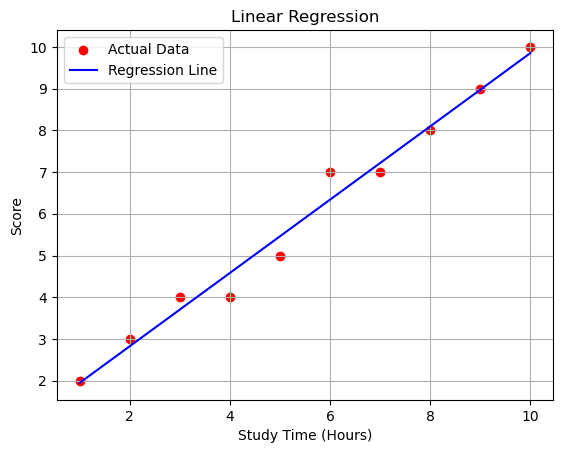

In [ ]:
plt.scatter(x, y, color='red', label='Actual Data')
plt.plot(x, y_pred, color='blue', label='Regression Line')
plt.xlabel("Study Time (Hours)")
plt.ylabel("Score")
plt.title("Linear Regression")
plt.legend()
plt.grid(True)
plt.show()


Additional Questions:

Q a. Consider the hepatitis/diabetes CSV file. Create a regression model and display the following:
Coefficients: B0 (intercept) and B1 (slope)
RMSE (Root Mean Square Error)
Predicted responses
b. Create a scatter plot of the data points in red color and plot the graph of x vs. predicted y in blue color.
c. Implement the model using two methods:
1.Pedhazur formula (intuitive)
2.Calculus method (partial derivatives, refer to class notes)
d. Compare the coefficients obtained using both methods. For a given data point, check the predicted y
value.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
df=pd.read_csv('Week 3 diabetes_csv.csv')

print(df.columns)

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')


In [ ]:
print(df.columns)

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')


In [ ]:
x = df["Glucose"].values
y = df["BMI"].values

n = len(x)
x_mean=np.mean(x)
y_mean=np.mean(y)
print("X Mean: ",x_mean)
print("Y Mean: ",y_mean)

X Mean:  120.89453125
Y Mean:  31.992578124999998


In [ ]:
B1 = np.sum((x - x_mean) * (y - y_mean)) / np.sum((x - x_mean)**2)
B0 = y_mean - B1 * x_mean
print("By Pedhazur Method:\n")
print("Slope(B1): ",B1)
print("Intercept(B0): ",B0)

y_pred=B0+B1*x
rmse = np.sqrt(np.mean((y - y_pred)**2))
print("RMSE:", rmse)
print("\nPredicted Responses")
print(y_pred)
error=y-y_pred
print("\nError: \n",error)

By Pedhazur Method:

Slope(B1):  0.05451413904153219
Intercept(B0):  25.40211683907664
RMSE: 7.684080516571635

Predicted Responses
[33.47020942 30.03581866 35.37820428 30.25387521 32.87055389 31.72575697
 29.65421968 31.67124283 36.14140223 32.21638422 31.39867213 34.5604922
 32.97958217 35.70528912 34.45146392 30.85353074 31.83478525 31.23512972
 31.01707316 31.67124283 32.27089836 30.7990166  36.08688809 31.88929939
 33.19763872 32.21638422 33.41569528 30.68998833 33.306667   31.78027111
 31.34415799 34.01535081 30.19936107 30.41741763 32.0528418  31.01707316
 32.92506803 30.96255902 30.30838935 31.45318627 35.21466187 32.65249733
 31.18061558 34.72403462 34.06986495 35.21466187 33.36118114 29.27262071
 31.01707316 31.12610144 31.01707316 30.90804488 30.19936107 34.99660531
 33.5792377  29.38164899 35.59626084 30.85353074 33.36118114 31.12610144
 29.98130452 32.65249733 27.80073896 33.08861044 31.61672869 30.7990166
 31.34415799 31.34415799 30.58096005 33.36118114 30.85353074 32.979

In [ ]:
sum_x = np.sum(x)
sum_y = np.sum(y)
sum_xy = np.sum(x * y)
sum_x2 = np.sum(x**2)
B1_calc = (n * sum_xy - sum_x * sum_y) / (n * sum_x2 - sum_x**2)
B0_calc = (sum_y - B1_calc * sum_x) / n
print("\nCalculus Method")
print("Intercept (B0):", B0_calc)
print("Slope (B1):", B1_calc)



Calculus Method
Intercept (B0): 25.402116839076623
Slope (B1): 0.05451413904153234


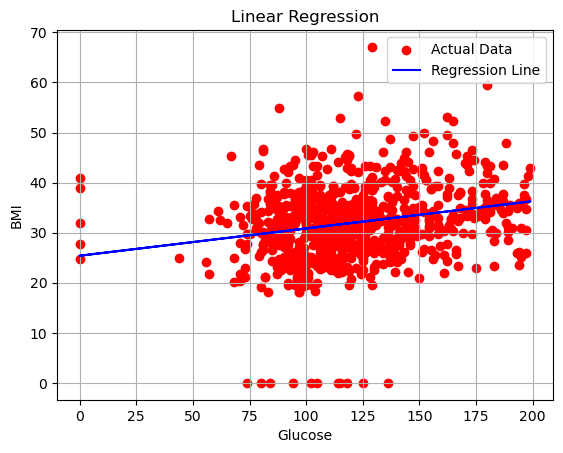

In [ ]:
plt.scatter(x, y, color='red', label='Actual Data')
plt.plot(x, y_pred, color='blue', label='Regression Line')
plt.xlabel("Glucose")
plt.ylabel("BMI")
plt.title("Linear Regression")
plt.legend()
plt.grid(True)
plt.show()
